## Q2 Part A)

### Question:
Compare:
- TF-IDF + Logistic Regression
- Word Embeddings + Neural Network

(a) Scalability & Generalization
(b) Limitations
(c) Why embeddings are powerful

**Answer**

1. TF-IDF + Logistic Regression
TF-IDF converts text into numbers based on word importance
It creates a large sparse vector (many zeros)
Logistic Regression uses these numbers to classify text
 Simple idea:
We manually convert text → then apply a basic model

2. Word Embeddings + Neural Network
Word embeddings convert words into dense vectors (with meaning)
Similar words have similar vectors (good ≈ great)
Neural networks learn patterns from these vectors

 Simple idea:
The model learns meaning automatically

**(a) Scalability & Generalization**

TF-IDF + Logistic Regression
Vocabulary increases → vector size increases
Leads to high memory usage
Cannot understand new or unseen words
No relationship between words
Result: Poor generalization

Embeddings + Neural Network
Uses fixed-size dense vectors (e.g., 100 or 300 dimensions)
Memory efficient
Understands similarity between words
Can handle new contexts better

Result: Better scalability and generalization


**(b) Limitations**

TF-IDF + Logistic Regression
No semantic meaning
“good” ≠ “excellent”
Ignores word order
Sparse vectors → inefficient
Cannot handle:
synonyms
context
multiple meanings of a word

Embeddings + Neural Network
Needs more data to train well
More complex and computationally expensive
Requires tuning (architecture, parameters)

**(c) Why Embeddings are Powerful**

Represent words in a meaningful vector space
Capture:
similarity (king ≈ queen)
relationships (Paris → France)
Reduce dimensionality (dense vectors)
Learn automatically from data
Work well with deep learning models

Key idea:
Embeddings don't just store words — they understand relationships between words

**Conclusion:**

TF-IDF with Logistic Regression is simple and effective for basic tasks but suffers
from high dimensionality and lack of semantic understanding. In contrast, word embeddings
with neural networks provide dense, meaningful representations, enabling better scalability,
 improved generalization, and more powerful language understanding.

# Q2 - part B)

### Explanation (Simple)

Word2Vec learns word meanings such that similar words are close in vector space.

Example:
King - Man + Woman ≈ Queen

In [2]:

sentences = [
    "king is a man",
    "queen is a woman",
    "man and woman are humans",
    "paris is capital of france",
    "rome is capital of italy"
]

sentences = [s.split() for s in sentences]
sentences


[['king', 'is', 'a', 'man'],
 ['queen', 'is', 'a', 'woman'],
 ['man', 'and', 'woman', 'are', 'humans'],
 ['paris', 'is', 'capital', 'of', 'france'],
 ['rome', 'is', 'capital', 'of', 'italy']]

In [4]:
!pip install gensim
from gensim.models import Word2Vec

model = Word2Vec(sentences, vector_size=50, window=3, min_count=1, sg=1)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 74.0 MB/s eta 0:00:00


In [5]:

model.wv.most_similar(positive=['king','woman'], negative=['man'])

[('are', 0.26551562547683716),
 ('and', 0.22561068832874298),
 ('is', 0.1763858199119568),
 ('paris', 0.03316398337483406),
 ('humans', -0.005148258525878191),
 ('italy', -0.012940265238285065),
 ('rome', -0.08153054863214493),
 ('france', -0.0818701684474945),
 ('a', -0.12880180776119232),
 ('of', -0.1614685207605362)]

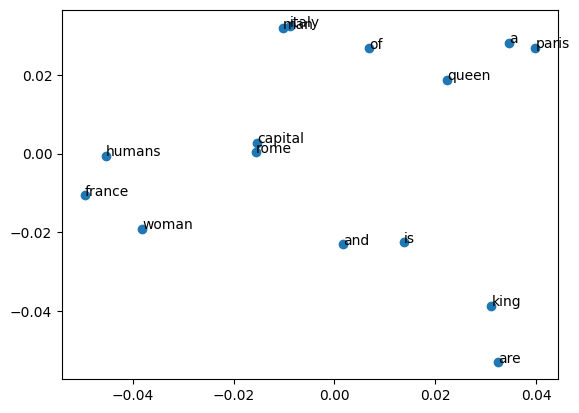

In [6]:

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words = list(model.wv.index_to_key)
vectors = [model.wv[w] for w in words]

pca = PCA(n_components=2)
result = pca.fit_transform(vectors)

plt.figure()
plt.scatter(result[:,0], result[:,1])

for i, word in enumerate(words):
    plt.annotate(word, (result[i,0], result[i,1]))

plt.show()


### (d) Model Choice
Skip-Gram is chosen because:
 Works better for small datasets
 Captures better semantic relationships

CBOW is faster but less accurate for such tasks

## Q2 Part C)


### (a) When Word2Vec Fails for Document-Level Tasks

Word2Vec is designed to learn embeddings for individual words, not complete documents.

To represent a full review, we usually average the word vectors. However, this approach has several problems:

- It treats all words equally, even though some words carry more meaning
- It ignores word order ("not good" vs "good")
- It loses the overall context of the sentence

Because of these issues, Word2Vec is not very effective for tasks that require understanding the full meaning of a document.

### (b) How Doc2Vec Solves This Problem

Doc2Vec extends Word2Vec by learning vectors for entire documents instead of just words.

- Each document is assigned a unique vector during training
- The model learns relationships between words and the document context
- It captures the overall meaning of the text instead of just individual words

This makes Doc2Vec much more suitable for document-level tasks like review classification.

### (c) End-to-End Pipeline for Review Classification

1. Data Collection:
   - Gather customer reviews and their labels (positive/negative)

2. Data Preprocessing:
   - Convert text to lowercase
   - Remove stopwords and punctuation
   - Tokenize the text into words

3. Feature Extraction:
   - Use Doc2Vec to convert each review into a fixed-size vector

4. Model Training:
   - Train a classification model such as Logistic Regression or a Neural Network

5. Evaluation:
   - Measure performance using accuracy, precision, recall, or F1-score

This pipeline ensures that the model learns meaningful patterns from entire reviews.

### (d) Connection to Modern LLMs (Conceptual Bridge)

Word2Vec and Doc2Vec were early approaches to learning representations of text.

However, they generate static embeddings, meaning each word or document has the same vector regardless of context.

Modern Large Language Models (LLMs) like BERT and GPT improve on this by generating contextual embeddings:

- The same word can have different meanings in different sentences
- The model understands context, grammar, and relationships better

Evolution of NLP models:

TF-IDF → Word2Vec → Doc2Vec → Transformers (BERT, GPT)

Doc2Vec acts as a bridge between simple word-based methods and advanced contextual models used today.

### Example: Doc2Vec Implementation

In [9]:

from gensim.models.doc2vec import Doc2Vec, TaggedDocument

reviews = [
    "this product is very good",
    "bad quality and not useful",
    "i love this item",
    "not worth the money"
]

tokenized = [r.split() for r in reviews]

tagged = [TaggedDocument(words=words, tags=[str(i)]) for i, words in enumerate(tokenized)]

model = Doc2Vec(tagged, vector_size=50, min_count=1, epochs=100)

model.dv['0'][:5]


array([-0.01254623, -0.01251476, -0.02206692,  0.01770646,  0.00655878],
      dtype=float32)